In [31]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.signal import find_peaks, peak_widths

import waveguide_solver as wgs

In [ ]:
# Extract data from Alex channel
data = np.loadtxt("densityProfile_ALEX_5.5ns.dat")
r_cm = data[:, 0]  # Assuming the first column is radius
n_e = data[:, 1]  # Assuming the second column is electron density

r_m = r_cm * 1e-2  # Convert radius from cm to m
n_e0 = 0.42e23 # On-axis density in m^-3
n_e_real = n_e * n_e0  # Scale the density profile to the actual on-axis density
print(r_m.shape)

r_scaling = 0.88
r_m_scaled = r_m * r_scaling

r_m_scaled = r_m_scaled[1:] # Remove the first point to avoid zero radius
n_e_real = n_e_real[1:] # Remove the first point to match the scaled

r_grid = np.linspace(0.5e-6, 500e-6, 1000)  # 1 µm to 500 µm
n_e_interp = np.interp(r_grid, r_m_scaled, n_e_real, right=0)  # Extrapolate with zero beyond the last point

r_cutoff = 100e-6  # 100 µm cutoff radius
n_e_interp[r_grid > r_cutoff] = 0

(876,)


In [33]:
lam = 815e-9 # wavelength (m)
n_cr = wgs.critical_density(lam)  # Critical density for 800 nm light
m = 0

k0 = 2 * np.pi / lam  # Free space wavenumber (m^-1)
beta_arr = np.linspace(0.9999, 1, 2000) * k0

beta_modes, eta_modes, beta_all, eta_all = wgs.find_eigenmodes(r_grid, k0, beta_arr, n_e_interp, n_cr, 
                                                               threshold=0.5, m=m, max_resolve_loops=7)

Performing initial coarse scan over beta values...


Calculating eta for beta values: 100%|██████████| 2000/2000 [00:53<00:00, 37.51it/s]


[2.21767469 1.09431864]
Found unresolved peaks at beta/k0 = [0.99992166 0.99997139], refining scan around these peaks...


Calculating eta for beta values: 100%|██████████| 12/12 [00:00<00:00, 46.36it/s]


[5.28014451 1.09431864]
Found unresolved peaks at beta/k0 = [0.99992168 0.99997139], refining scan around these peaks...


...

[16.2587074   1.44828519  1.24664178]
Found unresolved peaks at beta/k0 = [0.9999714 0.9999714], refining scan around these peaks...


Calculating eta for beta values: 100%|██████████| 12/12 [00:00<00:00, 46.90it/s]


[16.2587074   2.87144006  1.77014772  0.95111076  1.24664178]
Found unresolved peaks at beta/k0 = [0.9999714 0.9999714 0.9999714 0.9999714], refining scan around these peaks...


Calculating eta for beta values: 100%|██████████| 12/12 [00:00<00:00, 45.90it/s]

[16.2587074   1.28977557  1.10225305  2.94887184  1.77014772  0.95111076
  1.24664178]


(0.0, 48201.704189076365)

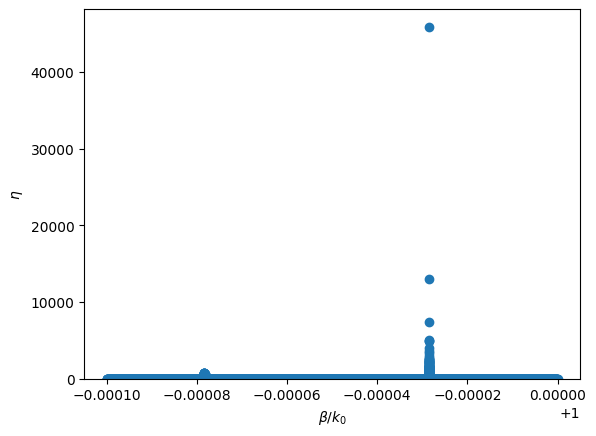

In [34]:
fig, ax = plt.subplots()
ax.scatter(beta_all / k0, eta_all)
ax.set_xlabel(r'$\beta / k_0$')
ax.set_ylabel(r'$\eta$')
# ax.set_xlim(0.99994150, 0.99994160)
ax.set_ylim(bottom=0)

Fundamental mode beta: 0.999971 m^-1


(0.0, 200.0)

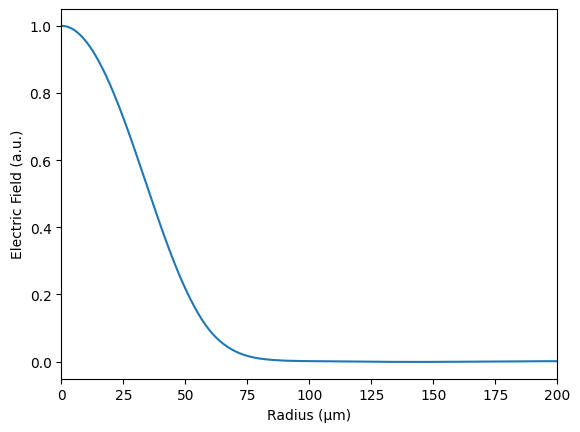

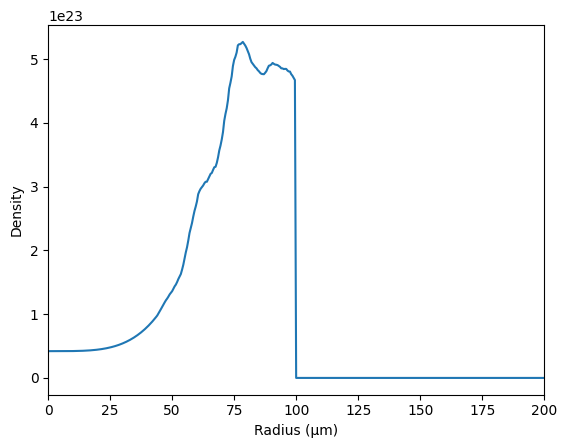

In [35]:
# Find the fundamental mode of the channel by looking for the maximum eta
max_eta_index = np.argmax(eta_all)
beta_fundamental = beta_all[max_eta_index]
print(f"Fundamental mode beta: {beta_fundamental/k0:.6f} m^-1")

kappa2 = wgs.transverse_wavenumber(n_e_interp, n_cr, k0, beta_fundamental)
mode_00 = wgs.solve_waveguide_fundamental_ivp(r_grid, kappa2, m=m)

fig, ax = plt.subplots()
ax.plot(r_grid * 1e6, mode_00, label='Fundamental Mode')
ax.set_xlabel('Radius (µm)')
ax.set_ylabel('Electric Field (a.u.)')
ax.set_xlim(0, 200)

fig, ax = plt.subplots()
ax.plot(r_grid * 1e6, n_e_interp, label='Fundamental Mode')
ax.set_xlabel('Radius (µm)')
ax.set_ylabel('Density')
ax.set_xlim(0, 200)

[ 448 1555]
Peak at beta/k0 = 0.999922 with eta = 714.2243
Peak at beta/k0 = 0.999971 with eta = 45906.3849
0.999971398358834


(0.0, 200.0)

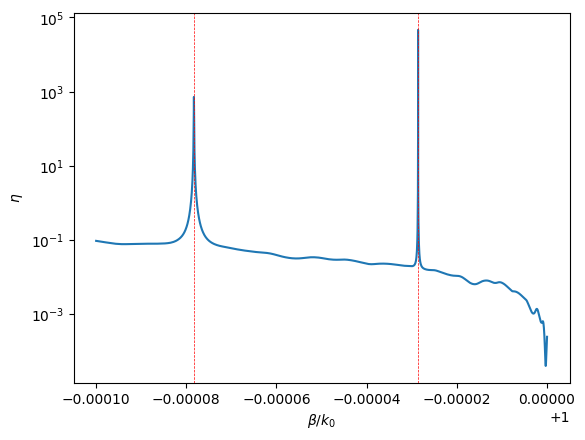

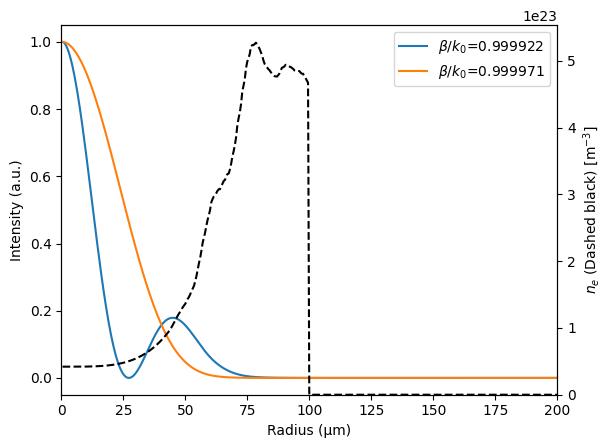

In [36]:
peaks, properties = wgs.find_peaks_rel_prominence(eta_all, threshold=0.9)
print(peaks)
for p in peaks:
    print(f"Peak at beta/k0 = {beta_all[p]/k0:.6f} with eta = {eta_all[p]:.4f}")

fig, ax = plt.subplots()
print(beta_all[np.argmax(eta_all)] / k0)

ax.plot(beta_all / k0, eta_all)
ax.set_yscale("log")
ax.set_xlabel(r'$\beta / k_0$')
ax.set_ylabel(r'$\eta$')
for p in peaks:
    ax.axvline(beta_all[p] / k0, color='red', linestyle='dashed', linewidth=0.5, label=f'Peak at beta/k0={beta_all[p]/k0:.6f}')
# ax.set_xlim(beta_all[np.argmax(eta_all) ] / k0 - 1e-7, beta_all[np.argmax(eta_all)] / k0 + 1e-7)

fig, ax = plt.subplots()
ax2 = ax.twinx()
ax2.plot(r_grid * 1e6, n_e_interp, linestyle="dashed", color="black")
ax2.set_ylabel(r"$n_e$ (Dashed black) [m$^{-3}$]", color="black")
ax2.set_ylim(bottom=0)

for p in peaks[-5:]:
    beta = beta_all[p]
    kappa2 = wgs.transverse_wavenumber(n_e_interp, n_cr, k0, beta)
    mode = wgs.solve_waveguide_fundamental_ivp(r_grid, kappa2, m=m)
    ax.plot(r_grid * 1e6, mode**2, label=f'$\\beta/k_0$={beta/k0:.6f}')
ax.set_xlabel('Radius (µm)')
ax.set_ylabel('Intensity (a.u.)')
ax.legend()
ax.set_xlim(0, 200)

In [40]:
# Calculate attenuation lengths for each peak
widths_1_m = wgs.calculate_L_att(beta_all, eta_all)

for p, width_1_m in zip(peaks, widths_1_m):
    print(f"Attenuation length for peak at beta/k0={beta_all[p]/k0:.6f}: {width_1_m:.2e} m")


Attenuation length for peak at beta/k0=0.999922: 2.71e+00 m
Attenuation length for peak at beta/k0=0.999971: 3.53e+02 m


0.999971398358834


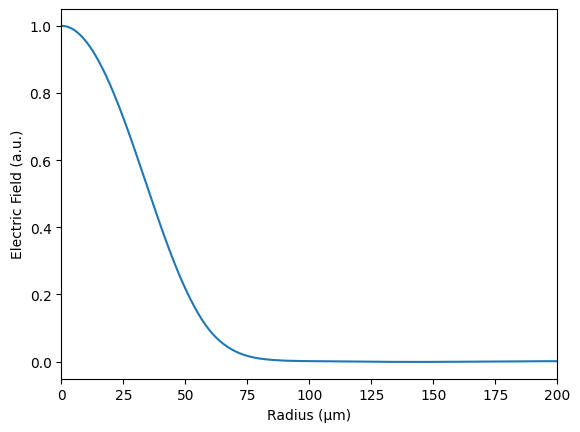

In [38]:
# Save the fundamental mode into a text file
beta_fundamental = beta_all[np.argmax(eta_all)]
print(beta_fundamental / k0)

kappa2 = wgs.transverse_wavenumber(n_e_interp, n_cr, k0, beta_fundamental)
mode = wgs.solve_waveguide_fundamental_ivp(r_grid, kappa2, m=m)

# Plot fundamental mode
fig, ax = plt.subplots()
ax.plot(r_grid * 1e6, mode, label='Fundamental Mode')
ax.set_xlabel('Radius (µm)')
ax.set_ylabel('Electric Field (a.u.)')
ax.set_xlim(0, 200)


data = np.column_stack((r_grid, mode))
np.savetxt("fundamental_mode.txt", data, header="Radius (m)    Electric Field (a.u.)")

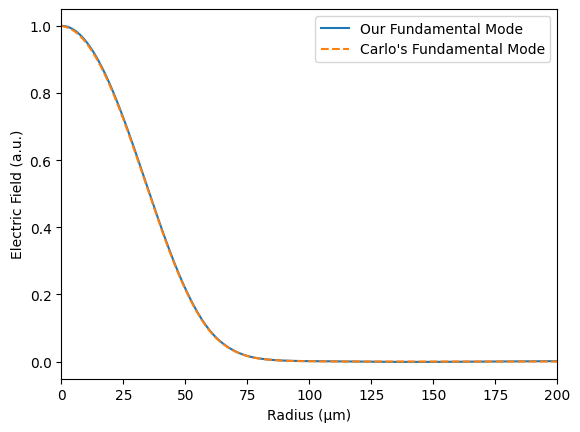

In [39]:
# Compare to carlo's mode solver
carlo_data = np.loadtxt("laserFieldTransverseProfile_LINEARLY_MATCHED_fundamental.dat")
carlo_r = carlo_data[:, 0] * 1e-6  # Convert from um to m
carlo_E = carlo_data[:, 1]  # Electric field values

fig, ax = plt.subplots()
ax.plot(r_grid * 1e6, mode, label='Our Fundamental Mode')
ax.plot(carlo_r * 1e6, carlo_E, label="Carlo's Fundamental Mode", linestyle="dashed")
ax.set_xlabel('Radius (µm)')
ax.set_ylabel('Electric Field (a.u.)')
ax.set_xlim(0, 200)
ax.legend()